## Feature Extraction, Clustering, and Dimensionality Reduction using PCA

In this section, we will perform feature extraction and clustering on our dataset. We will use Principal Component Analysis (PCA) to reduce the dimensionality of the data.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from helper.tools import PrincipalComponentAnalysis
from sklearn.cluster import KMeans


# plot settings
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams["lines.linewidth"] = 2


In [22]:
# load data
df = pd.read_pickle('../processed_data/dataInterpolated.pkl')
columns = list(df.columns[1:7])
columns_acc = list(df.columns[1:4])
columns_gyro = list(df.columns[4:7])

### **Principal Component Analysis (PCA)**

In [23]:
PCA = PrincipalComponentAnalysis()
df_pca = df.copy()

values = PCA.pca_variance(df_pca, columns)

#### ELBOW TECHNIQUE

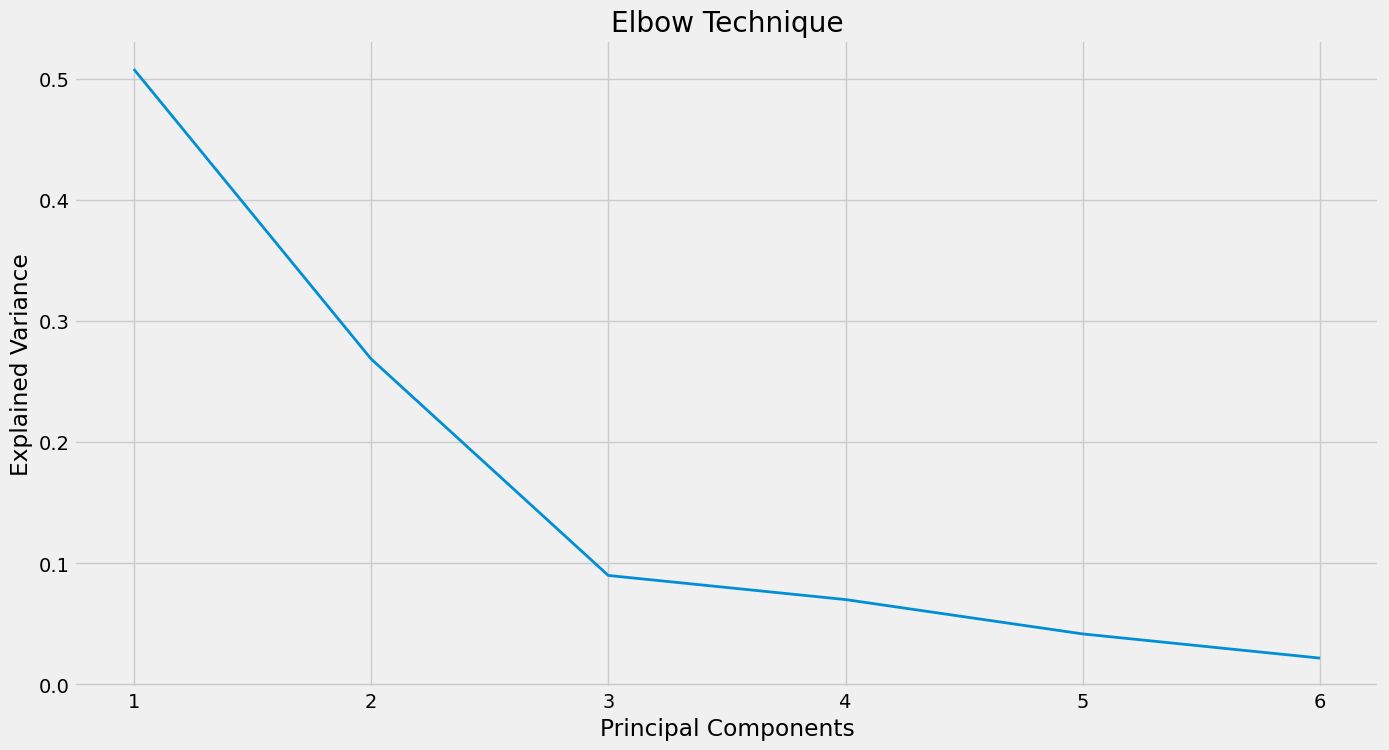

In [24]:
# Elbow technique
plt.figure(figsize=(15, 8))
plt.plot(range(1, len(columns) + 1), values)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Elbow Technique")
plt.show()

In [25]:
# Apply PCA
df_pca = PCA.apply_pca(df_pca, columns, 3)

#### **SQUERED**

In [26]:
df_squered = df_pca.copy()
Accelerometer_r = df_squered["Accelerometer_x"]**2 + df_squered["Accelerometer_y"]**2 + df_squered["Accelerometer_z"]**2
Gyroscope_r = df_squered["Gyroscope_x"]**2 + df_squered["Gyroscope_y"]**2 + df_squered["Gyroscope_z"]**2

df_squered["Accelerometer_r"] = np.sqrt(Accelerometer_r)
df_squered["Gyroscope_r"] = np.sqrt(Gyroscope_r)

#### **PCA and SQUARE PLOTS**

array([<Axes: >, <Axes: >], dtype=object)

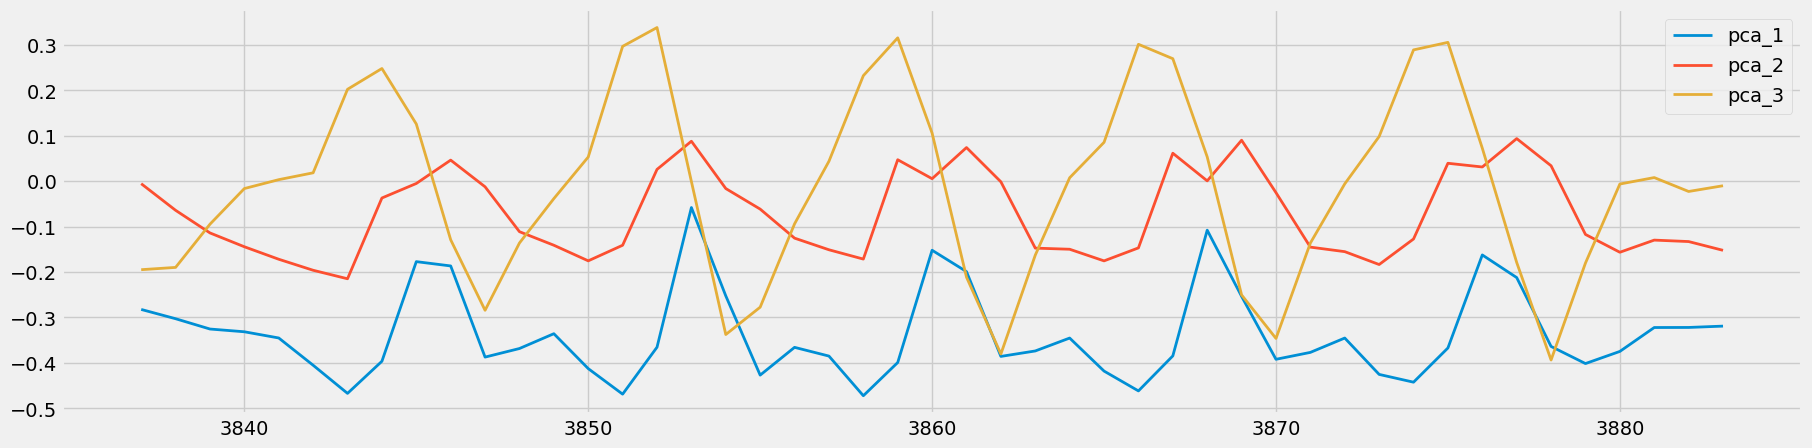

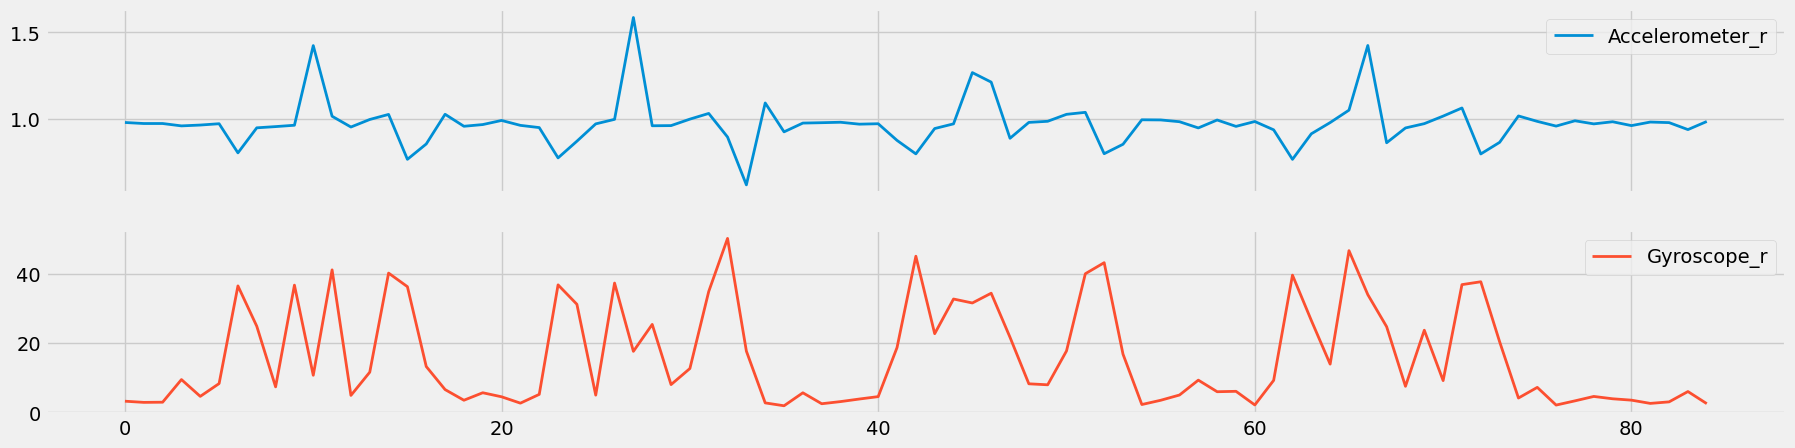

In [27]:
# in this case wee see that the data have noise
subset = df_pca[df_pca["Set"] == 35]
subset[["pca_1", "pca_2", "pca_3"]].plot()

subset = df_squered[df_squered["Set"] == 30]
subset[["Accelerometer_r", "Gyroscope_r"]].plot(subplots=True)

In [28]:
df_squered["Label"].value_counts()

Label
ohp      1676
bench    1665
squat    1610
dead     1531
row      1417
rest     1110
Name: count, dtype: int64

#### **CLUSTERING**

##### - acceletrator_colums

In [29]:
df_cluster = df_squered.copy()
kvalues = range(1, 10)
inertia_acc = []

for k in kvalues:
    subset = df_cluster[columns_acc]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset) 
    inertia_acc.append(kmeans.inertia_) 

# using elbow technique to determine the number of clusters
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster[columns_acc]
df_cluster["cluster_acc"] = kmeans.fit_predict(subset)


##### - gyroscope_colums

In [30]:
inertia_gyr = []
for k in kvalues:
    subset = df_cluster[columns_gyro]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset)
    inertia_gyr.append(kmeans.inertia_)

# using elbow technique to determine the number of clusters
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster[columns_gyro]
df_cluster["cluster_gyro"] = kmeans.fit_predict(subset)


#### **PLOTS**

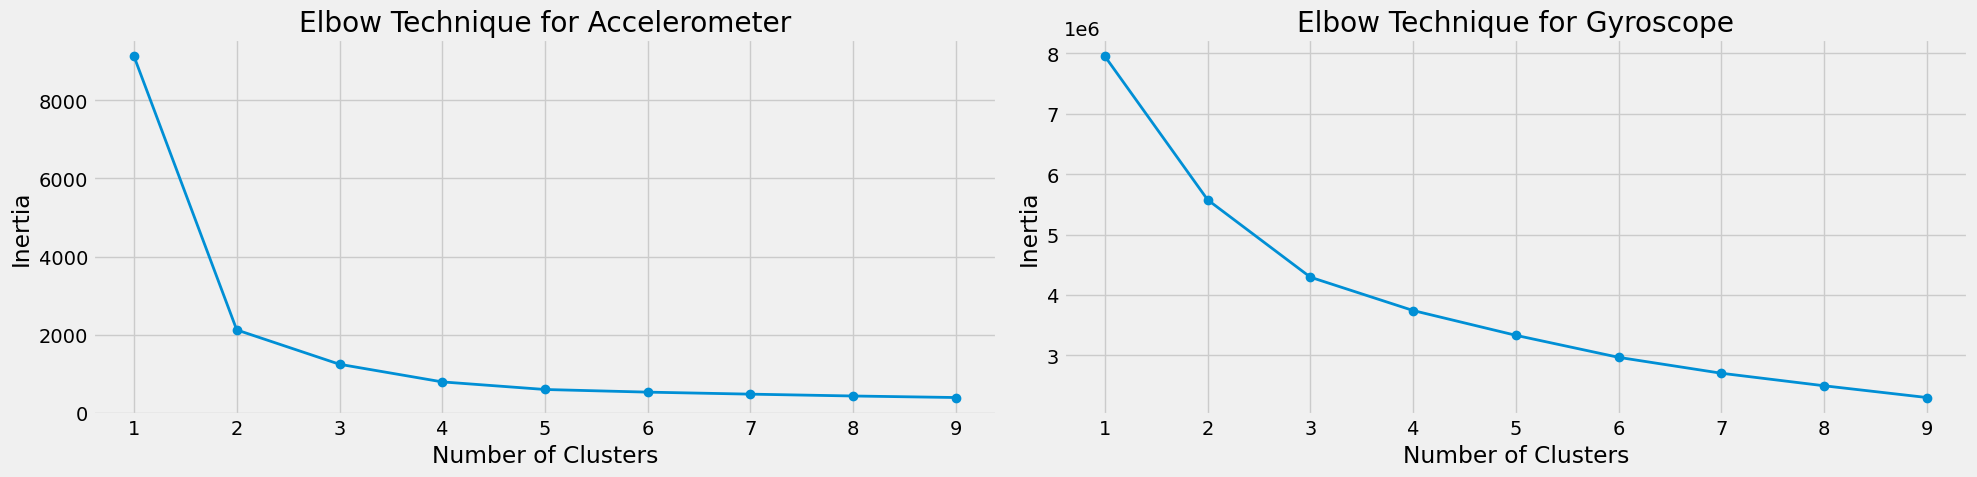

In [31]:
# Accelerometer
plt.subplot(1, 2, 1)
plt.plot(kvalues, inertia_acc, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Accelerometer")

# Gyroscope
plt.subplot(1, 2, 2)
plt.plot(kvalues, inertia_gyr, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Gyroscope")

plt.tight_layout()
plt.show()

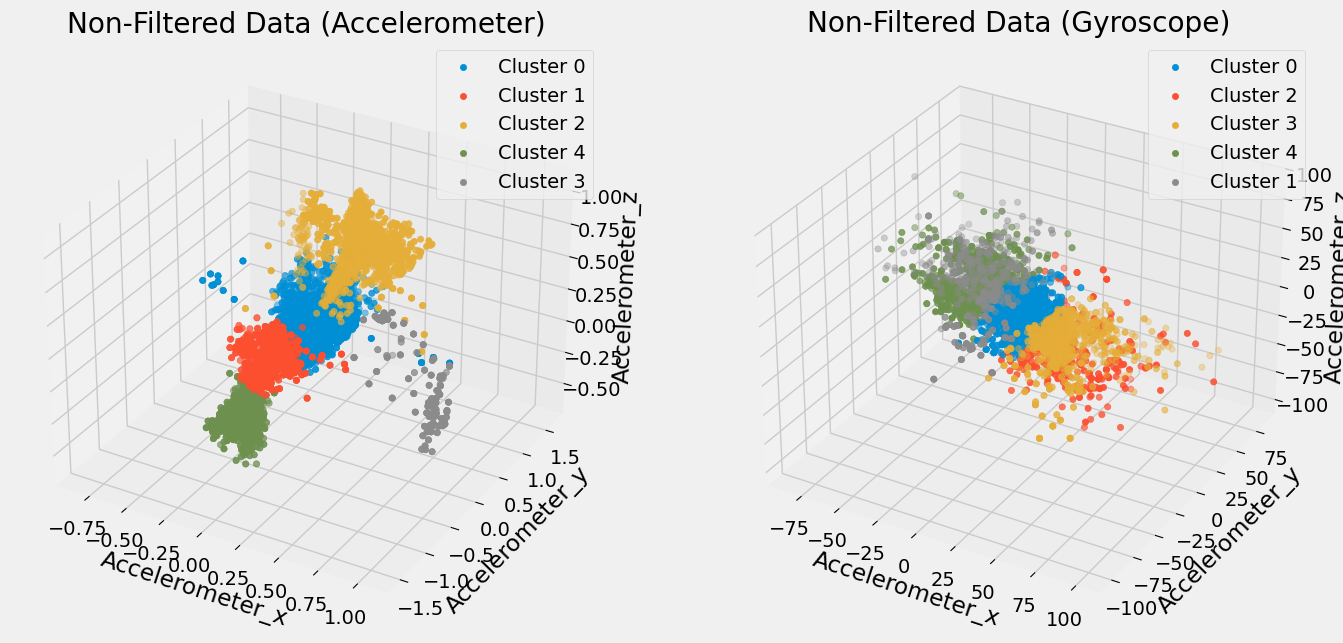

In [32]:
# plot the clusters for accelerometer
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(121, projection='3d')
for c in df_cluster["cluster_acc"].unique():
    subset = df_cluster[df_cluster["cluster_acc"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Non-Filtered Data (Accelerometer)")
plt.legend()

# plot the clusters for gyroscope
ax = fig.add_subplot(122, projection='3d')
for c in df_cluster["cluster_gyro"].unique():
    subset = df_cluster[df_cluster["cluster_gyro"] == c]
    ax.scatter(subset["Gyroscope_x"], subset["Gyroscope_y"], subset["Gyroscope_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Non-Filtered Data (Gyroscope)")
plt.legend()

plt.show()

In [33]:
# save the data
#df_cluster.to_pickle('../processed_data/modelData.pkl')

## Exctracting using furier transformation and the filtering to filter the data